# PCHN63101 Statistical Modelling Workshop
In the accompanying lesson to this workshop we explored the general concept of a statistical model as a method of capturing the variance inherent within a dataset. We first saw how to define a descriptive measure of variance, before exploring how this notion of random variation can be formalised using concepts from the world of *probability*. Specifically, every value we measure is conceptualised as a random draw from a particular probability distribution. This distribution provides the *model* of our data-generating process and thus formalises the probabilistic behaviour of our measurements. The shape of every probability distribution is controlled by a number of *parameters* that, either directly or indirectly, inform the *expected value* and *variance* of the distribution. These can be thoughts of as the *most probable* value and the *width*. A statistical model is then concerned with assuming some population distribution for a given data set and then connecting the parameters of the distribution to the data via a *mean function* and a *variance* function.    

At present, some of these ideas may feel a bit abstract. However, over the coming weeks we will start to see them put into action and all this information should become more concrete. In this workshop, the focus will be on providing more intuition about all these topics. In part, this will involve demonstrating some of these ideas in code so that you can play around with them, get a feel for them and see how the output changes with different inputs and arguments. In general, playing with code is one of the *best* ways for gaining intuition about more abstract mathematical concepts.

## Understanding Variance
To begin, we will start with the basic concept of variance as the degree to which measured data points *differ* from each other. You should understand from the lesson one way in which we can capture this degree of variation, through the calculation of the sample variance. The equation for the sample variance is

$$
\text{Var}\left(y\right) = \frac{\sum\left(y_{i} - \bar{y}\right)^{2}}{n-1}
$$

where $n$ indicates the sample size, $\bar{y}$ indicates the mean and the symbol $\Sigma$ indicates a sum across all the data points (if you are unfamiliar with this notation, we will explain it in more detail in a future lesson). Although not the only conceivable way of capturing how much data differs, this is the formal definition of *variance* within statistics. We can see in the plots below that this value scales with our visual intuition about *variation* as the *spread* of values around 0. 

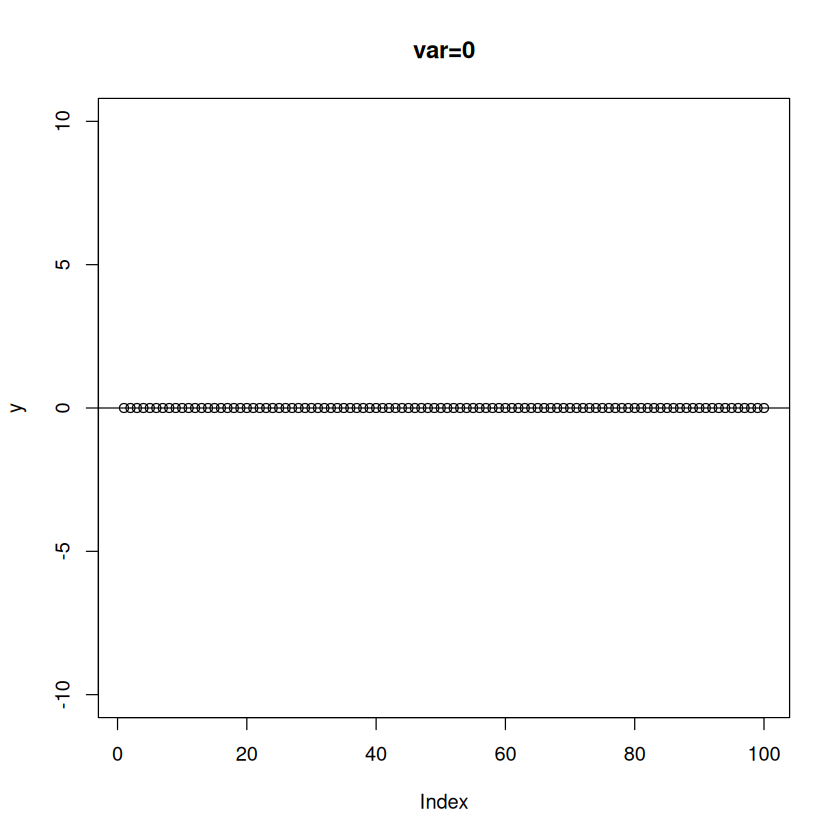

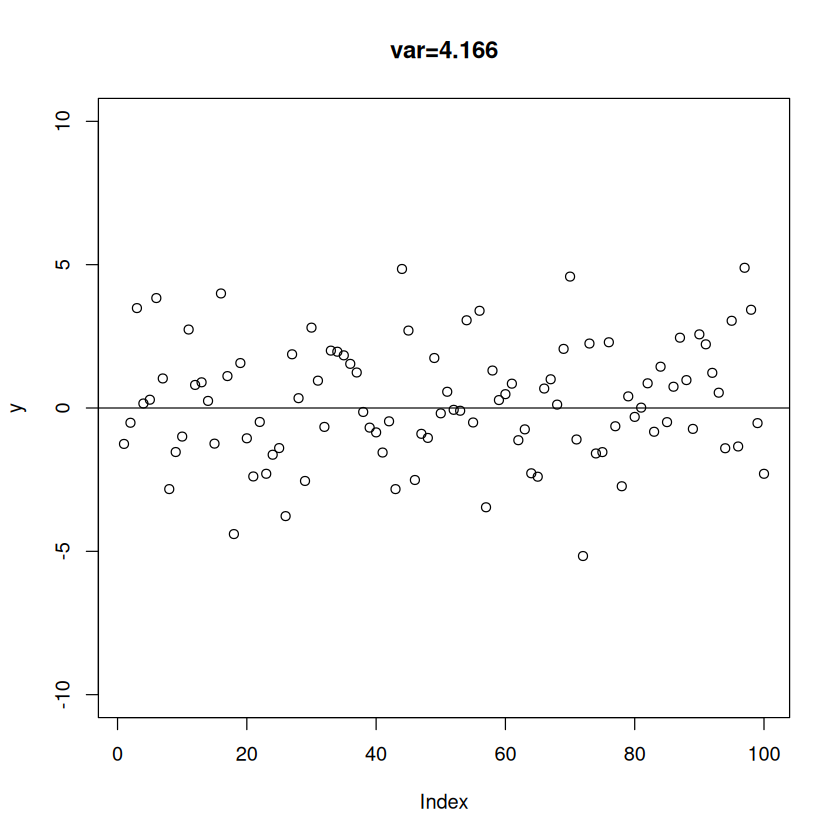

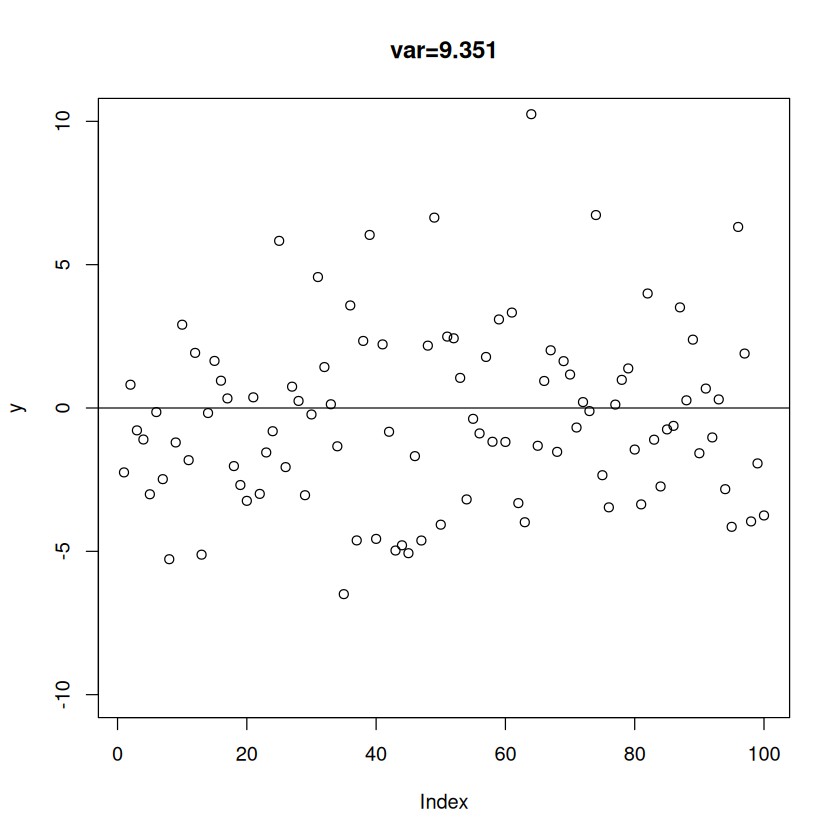

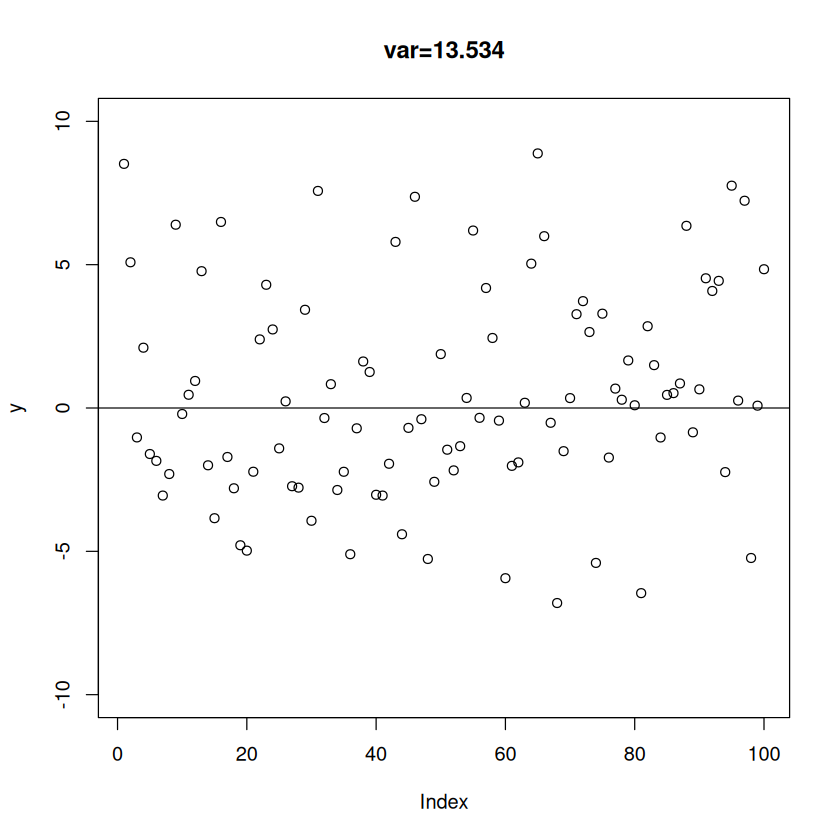

In [1]:
set.seed(123)
for (i in 0:3){
   y      <- rnorm(n=100, mean=0, sd=sqrt(i*5))
   sigma2 <- var(y)
   plot(y, ylim=c(-10,10), main=paste0("var=",round(sigma2,3)))
   abline(h=0)
}

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Try replacing the use of the <code>var()</code> function above with the full equation for the sample variance. Check the output against the values given by <code>var()</code> to make sure you have got this right. HINT: if you are using the equation above, you can replace &Sigma; with the <code>sum()</code> function and &#563; with the <code>mean()</code> function.
</div>

## Sources of Variance
Although we can now see how variance can be captured, this is only ever a precursor to trying to *explain* variance. A core concept here is that data can vary for *two* reasons: systematic patterns, or random noise. Consider the code below and the resultant plots

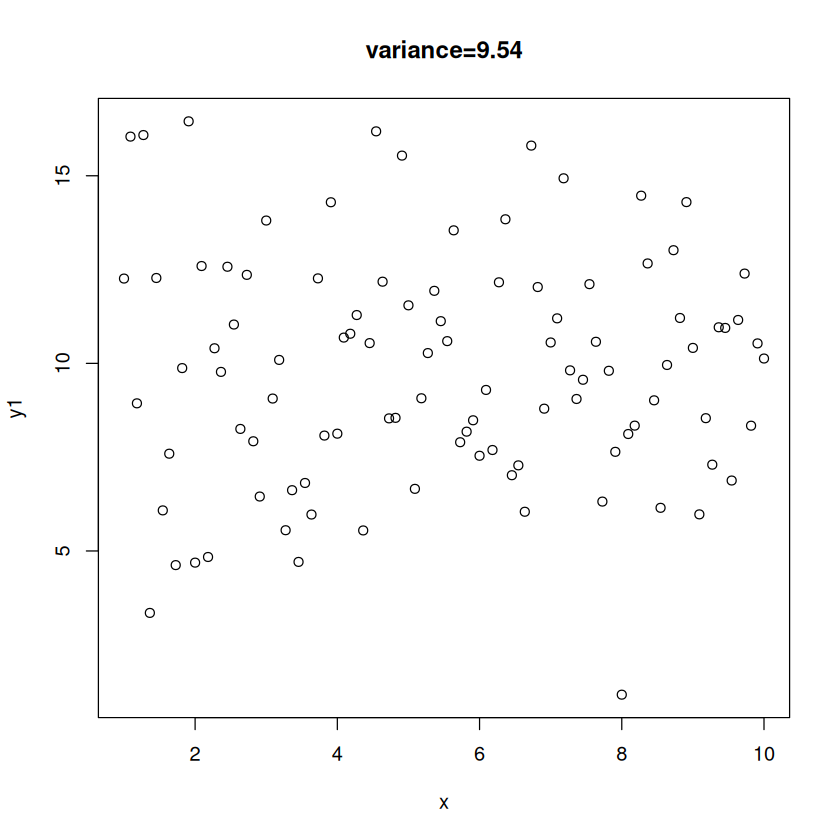

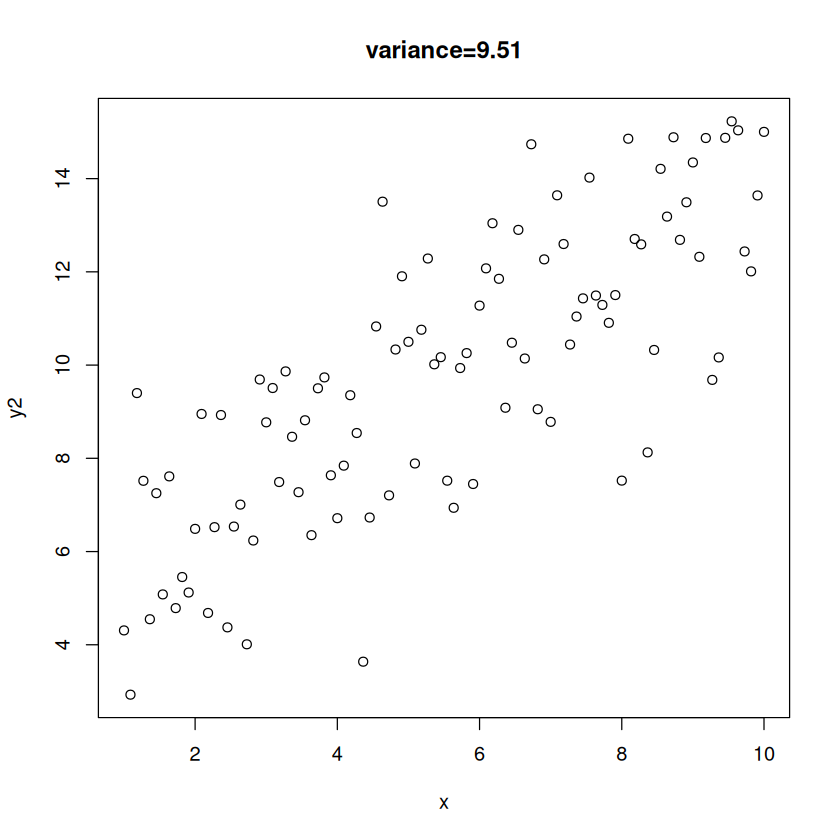

In [2]:
set.seed(666)
x <- seq(1, 10, length.out = 100)

y1 <- rnorm(100, 10, 3)                 # pure noise
y2 <- (5 + 0.9*x) + rnorm(100, 0, 1.68) # linear pattern + pure noise

var1 <- round(var(y1),2)
var2 <- round(var(y2),2)

plot(x, y1, main=paste0("variance=",var1)) 
plot(x, y2, main=paste0("variance=",var2))


The first plot contains random noise drawn from $\mathcal{N}\left(10,3\right)$, which is completely unrelated to the predictor variable $x$. The second plot contains a linear pattern between $x$ and $y$, with some random noise added. Both sets of data have nearly the same measurment of variance, yet the second one has a much clearer pattern between $x$ and $y$. This highlights that variance in and of itself cannot tell us whether the variation is systematic or random. That is the job of the statistical model. Any patterns within the data are taken as the *predictable* elements, whereas the additional random noise represents the *unpredictable* elements. The job of any statistical model is to take the total amount of variance in the data and try to *split it* into the amount attributable to predictable patterns, and the amount attributable to random noise.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Imagine that the second plot above corresponds to an investigation into how mood, as measured using a questionnaire, improves based on the number of hours sleep someone gets the night before. Redraw the plot so that the x-axis is labelled <code>hours of sleep</code> and the y-axis is labelled <code>mood</code>. Despite collecting data from 100 different people, there appears to be some universal pattern between hours of sleep and mood. However, the relationship is not perfect. Why is that? Can you think of different reasons why we still have an <i>unpredictable</i> element to these data?
</div>

### Reducible and Irriducible Error
The idea of splitting variance into a *systematic* component and a *random noise* component relates to a key idea in statistics of *reducible* and *irriducible* error. For example, using the sleep and mood example, if we measured mood but had not measured hours of sleep, we would have no way of capturing the relationship we see above. The variance associated with this relationship would therefore get partitioned into the *random noise* component and the model error would be larger. However, if we include hours of sleep in our model, this relationship is captured, the *systematic* variance gets larger and the *random noise* gets smaller. We have therefore *reduced* the model error and so this is an example of *reducible* error. However, even with every measurement in the world we could never capture all the reasons why data varies, as there will always be some element that is just random noise. This is the *irreducible error*. We cannot get rid of it by making our model better and better because there will always be some element of real-world data that cannot be predicted. Our aim when building a statistical model is therefore to account for as much reducible error as possible, knowing that there will always be some amount of irreducible error. In other words, we want our model as good as possible, but knowing that it can never be perfect.

## Random Variables as Variance Generators
Knowing that variance, both systematic and random, is the primary information we want to capture leads to the obvious question of *where does variance come from*? Although the true reasons for variation in measurements are likely to be deep and complex, this question can be more simply addressed by appealing to probability. The reason our measurements vary is because the phenomena we are measuring is a *random variable*. By definition, this means that every time we make an observation, the value will change. Although this change is *unpredictable* in the short-term, it has a regularity and pattern in the long-term, as governed by its *probability distribution*. The parameters of the probability distribution control its shape and thus control both the *predictable* and *unpredictable* elements of the data.

When conceptualising our measurements as realisations of a random variable, we can think of the random variable as the *variance generator*. Of course, the probability distribution is a mathematical idealisation of the real world, so it is more accurate to say that the random variable is a *model* of the variance we observe in real data. The distribution is our proposed *data-generating process*. It tells us, in an idealised mathematical fashion, *where the data came from*. As such, understanding the nature of probability disributions is central to all parametric statistical techniques. The core idea is that if we know the distribution and parameter values that generated the data, we can answer all the questions we have about the data.   

### Discrete Outcome Example
Imagine an experiment where subjects are exposed to a series of very faint auditory stimuli. After each presentation, they are asked whether they heard anything or not. In total, each subject takes part in 20 trials, where the outcome variable is a count of the number of "yes" responses. This variable can be modelled as a *binomial random variate* of the form

$$
y_{i} \sim \mathcal{B}\left(n,p\right).
$$

We already know that $n=20$, because each subject takes part in 20 trials. Let us say, for the purpose of illustration, that we know that the stimuli are around around 60% detectable, so $p=0.6$. Thus, our proposed data-generating process is

$$
y_{i} \sim \mathcal{B}\left(20,0.6\right).
$$

Here, the variation in the count of "yes" responses across subjects is generated by the fact that this is a Binomial random variate drawn from a distribution with a *mean* and *variance*. These elements control both what the average count of "yes" responses is, as well as how variable this count will be on average. Thus, everything we need to know about this experiment is captured in the data-generating model above.

We can use `R` to simulate data like this. For instance, we can generate 50 subjects from this experiment like so

In [3]:
y <- rbinom(n=50, size=20, prob=0.6)
y

[1]  8 10  9 13 13 13  9 10 11 11 12 13  8  8  9 10  9 13 12 13 11 12 11 13 11
[26] 12 13 15 14 14 10 14 13 10 10 13 13 12 13 13 15 12 12 14 10 10 15 10 10  8

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Try running this code a few times. Do you get the same values? Is there any way to predict what those values will be? Think about what this represents in terms of running an experiment again and again with different subjects.
</div>

It should be clear at this point that we have no way of predicting what any single response will be, nor how this will change from subject to subject. Thus, this variable is *unpredictable* in the short-term. This is the random noise component. However, in the *long-term* there is a pattern that we can use to make *general* predictions about the data. This is the systematic component. 

Both the *random noise component* and *systematic component* are described by different elements of the probability distribution. The random noise is captured by the *variance* and the systematic pattern is captured by the *expected value* (the *mean*). All probability distributions have some concept of both these elements. For the Binomial distribution, these are linked to the parameters in the following way

$$
\begin{alignat*}{1}
    E(y_{i})   &= np \\
    \text{Var}\left(y_{i}\right) &= np(1-p)
\end{alignat*}
$$

Thus, we can say how many "yes" responses we expect on average and how variable those responses are expected to be from subject-to-subject.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Create a histogram of the data generated from the binomial distribution above. Try calculating the expected value and variance using the formulas above. Do they appear to agree with what you can see? Try calculating these directly from the data using the <code>mean()</code> and <code>var()</code> functions. Are they close to the values calculated directly from the parameters? What happens if you make the sample size very large (i.e. 10,000)?
</div>

### Continuous Outcome Example
As another example, consider the same experiment concerned with the detection of faint auditory stimuli. This time, rather than subjects responding "yes" or "no", we ask them to press a button as soon as they are certain they can hear something. We then measure their *reaction time* (RT) in milliseconds from the start of the auditory stimulus to when they press the button to indicate they can hear it. Because RT is a continuous measure, we can therefore use a continuous distribution as our model. The usual choice would be to treat RT as a *normal random variate* of the form

$$
y_{i} \sim \mathcal{N}\left(\mu, \sigma^{2}\right)
$$

Again, for the purpose of illustration, let us say that we know that, on average, subjects can detect the stimuli within around 500ms, varying by around 50ms on average. So we can set $\mu = 500$ and $\sigma = 50$.

As with the binomial example, we can use `R` to simulate 50 subjects from this experiment.

In [4]:
y <- rnorm(n=50, mean=500, sd=50)
y

[1] 503.1741 575.4391 508.9341 499.3204 494.0447 511.8733 486.6972 538.4866
 [9] 542.2793 522.8187 507.4697 419.5052 506.0922 442.7916 462.7511 532.5251
[17] 417.6543 445.6637 469.5890 486.5716 509.4749 527.9992 532.6453 431.8599
[25] 548.3474 476.1442 514.0300 499.3936 473.5064 543.7936 459.7594 585.1778
[33] 429.5687 475.4642 513.3095 408.8970 576.4397 486.4467 519.5314 464.6586
[41] 428.2903 518.9568 550.4450 467.7135 477.3212 489.0742 380.0473 438.7291
[49] 497.3842 405.3594

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Beyond the magnitude of these values, what is the most obvious difference between drawing data from a binomial distribution and data from a normal distribution? What does this tell you about the suitability of these distributions for different kinds of data?
</div>

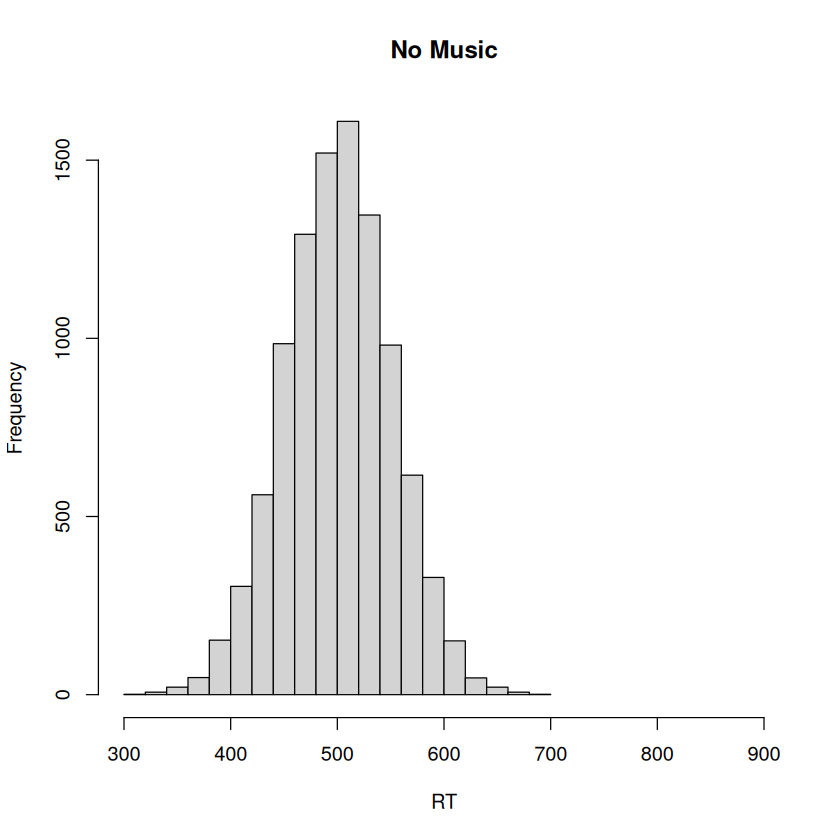

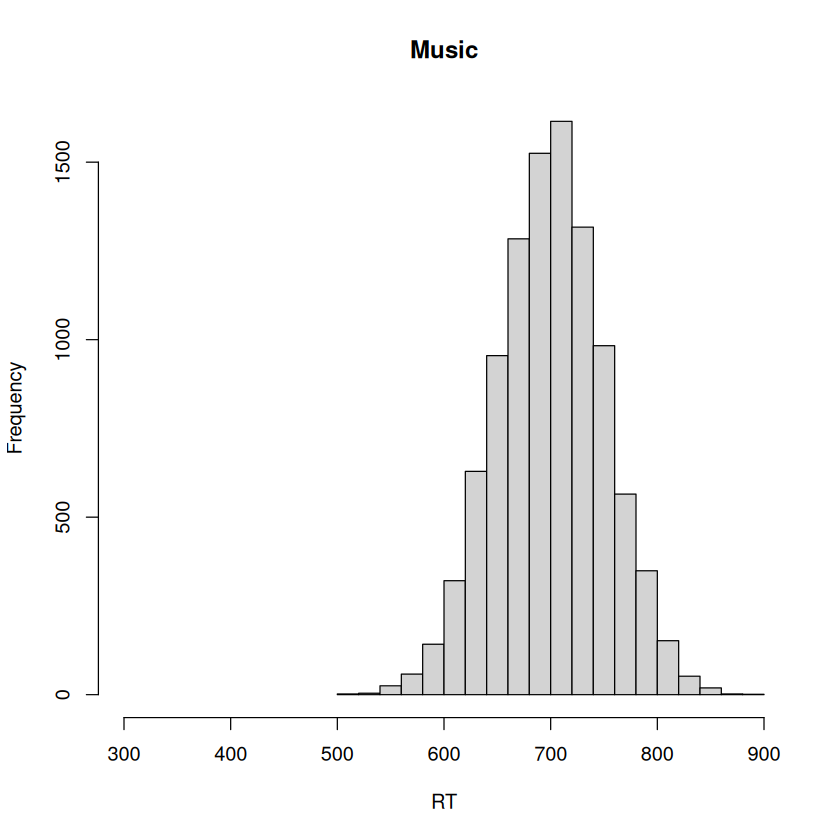

In [5]:
y.nomusic <- rnorm(n=10000, mean=500, sd=50)
y.music   <- rnorm(n=10000, mean=700, sd=50)
hist(y.nomusic, xlim=c(300,900), breaks=20, main="No Music", xlab="RT")
hist(y.music,   xlim=c(300,900), breaks=20, main="Music",    xlab="RT")

## Mean Functions and Variance Functions
So far, all the distributions we have seen have used a *constant value* for their parameters. In terms of trying to model complex data, this is too limited. A much more flexible approach is to define a *mean function* and a *variance function*. These allow the expected value and the variance of the distribution to change depending upon the values of other variables. This embeds the idea that under different circumstances, we may be sampling data from *different* distributions.

<div class="alert alert-block alert-danger"> 
<b>KEY POINT</b> You can think of the mean function and variance functions as  <i>rules</i> that dictate what value the mean will have and what value the variance will have, depending upon the specific observation. For instance, what value does the mean have when data come from one experimental condition versus another?
</div>

### Normal Example
We will start with the example of a normal distribution, because this will be simpler than the binomial example. In both cases, we can use `R` to define functions in code for both the mean and variance. This is helpful because it shows how the more abstract principles of a mathematical models can be translated into code. If you find code easier to understand, this can really help with your understanding.

To begin with, the most basic form of a *mean* and *variance* function for the normal distribution is as follows

$$
\begin{alignat*}{1}
    y_{i}              &\sim \mathcal{N}\left(\mu_{i},\sigma^{2}_{i}\right) \\
    E(y_{i})           &= \mu_{i}                             \\
    \text{Var}(y_{i})  &= \sigma^{2}_{i}. 
\end{alignat*}
$$

In words, this says that observation $i$ is drawn from a normal distribution parameterised by a mean $\mu_{i}$ and variance $\sigma^{2}_{i}$. The *expected value* (i.e. the mean) is just given by $\mu_{i}$ and the *variance* is just given by $\sigma^{2}_{i}$. 

The *mean function* is then whatever rule we use to assign a numeric value to $\mu_{i}$. For instance, we might define that $\mu_{i} = 5$. Thus the mean function states that, irrespective of the value of $i$, the mean will always be 5. For each observation, we therefore ask the mean function "what mean value should observation $i$ have?" and the mean function returns us the value based on its rules. We can also do the same with the variance function, where the simplest case would be a constant value such as $\sigma^{2}_{i} = 2$.

Let us see how we could implement this as a *data simulation* in `R`.

In [ ]:
mean.func <- function(i){
    mu <- 5
    return(mu)
}

var.func <- function(i){
    sigma2 <- 2
    return(sigma2)
}

y <- rep(0,50)
for (i in 1:50){
    y[i] <- rnorm(n=1, mean=mean.func(i), sd=sqrt(var.func(i)))
}

At present, this is just an overly-complicated way of writing `rnorm(n=50, mean=5, sd=sqrt(2))`. However, we will now see how we can use this *structure* to adapt the model so that the parameter $\mu_{i}$ changes depending upon the condition of the experiment. This will lead to a data-generating model that can *accommodate* our experimental manipulations.

### Binomial Example
To start with, we will see how we can use `R` to define functions for both the mean and variance of a binomial distribution. This can be helpful because it shows how the principles of mathematical models translate into code. If you find code easier to understand, this can really help with understanding. To begin with, the most basic form of a *mean* and *variance* function for the binomial distribution is as follows

$$
\begin{alignat*}{1}
    y_{i}              &\sim \mathcal{B}\left(n_{i},p_{i}\right) \\
    E(y_{i})           &= n_{i}p_{i}                             \\
    \text{Var}(y_{i})  &= n_{i}p_{i}\left(1 - p_{i}\right). 
\end{alignat*}
$$

In words, this says that observation $i$ is drawn from a binomial distribution parameterised by a parameter $n_{i}$ (the number of trials) and $p_{i}$ (the probability of saying "yes"). The *expected value* (i.e. the mean) is given by $n_{i}p_{i}$. This is the *mean function*. The *variance* is given by $n_{i}p_{i}\left(1 - p_{i}\right)$. This is the *variance function*.

Because this can seem a bit abstract, let us see how we could implement this as a *data simulation* in `R`. To make this simple, we will fix the values of $n_{i} = n = 20$ and $p_{i} = p = 0.6$. So these values are *constant* irrespective of the particular observation. This can all be written as follows 

In [23]:
mean.func <- function(i){
    n <- 20
    p <- 0.8
    return(n*p)
}

var.func <- function(i){
    n <- 20
    p <- 0.8
    return(np*(1-p))
}

n <- 20
y <- rep(0,50)

for (i in 1:50){
    y[i] <- rbinom(n=1, size=n, prob=mean.func(i)/n)
}

At present, this is just an overly-complicated way of writing `rbinom(n=50, size=20, prob=0.8)`. However, we will now see how we can use this *structure* to adapt the model so that the parameter $p$ changes depending upon the condition of the experiment. This will lead to a data-generating model that can *accommodate* our experimental manipulations.

#### Modelling an Experimental Manipulation
Now imagine that we perform some sort of experimental manipulation. For instance, perhaps we get a different group of subjects to listen to some very loud music for 5 minutes. We then get them to try and detect the same faint auditory stimuli as well. Assuming that this manipulation makes subjects *worse* at detecting the stimuli, we could conceptualise this as a shift in the probability of saying "yes". In other words, the experimental manipulation has caused $p$ to change. For instance, perhaps after listening to the loud music, $p = 0.3$ and the data-generating process becomes

$$
y_{i} \sim \mathcal{B}\left(20,0.3\right).
$$

We can again use `R` to simulate this type of data

In [6]:
y <- rbinom(n=50, size=20, prob=0.3)
y

[1]  7  9  3  8  6  6  6  6  9  8  5 10  6  7  5  4  7  7  6  8  6  6  5 10  5
[26]  7  4  4  5  5  5  9  5  6  5  6  8  6  8  6  5  8  4  6  8  7  5 12 13  4

Much like before, we have no way of predicting any single response here. However, we can see a general pattern where the number of "yes" responses has been *reduced* compared to before. So, we can conceptualise the effect of our experiment as a *shift* in the parameters of the data-generating distribution. Alternatively, we can think of the data from each condition as being drawn from a *different* binomial distribution. We can see this illustrated in the histograms below.

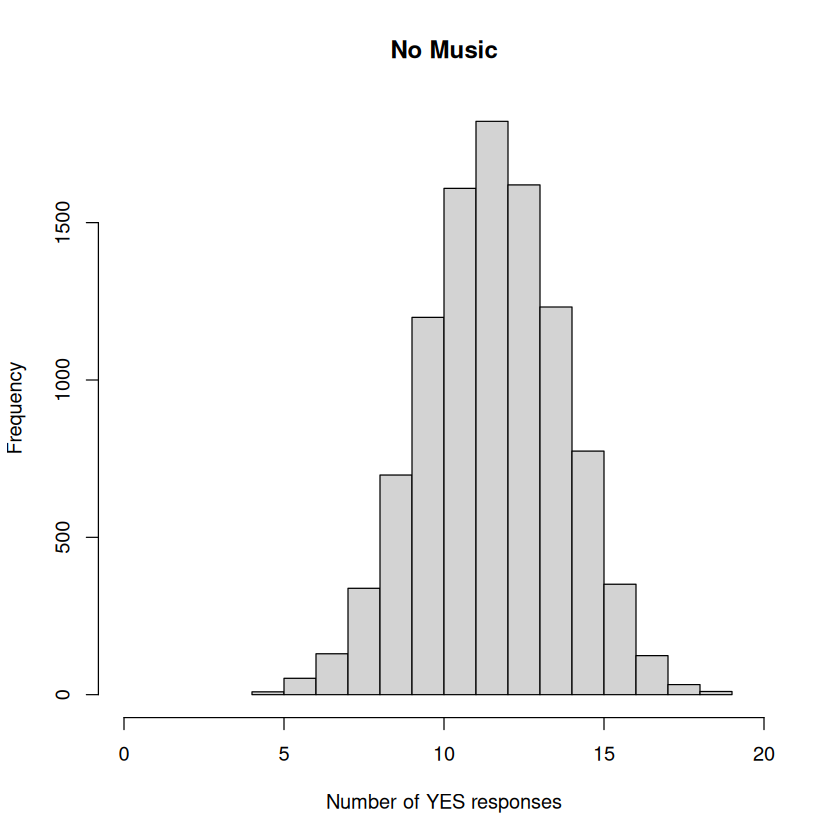

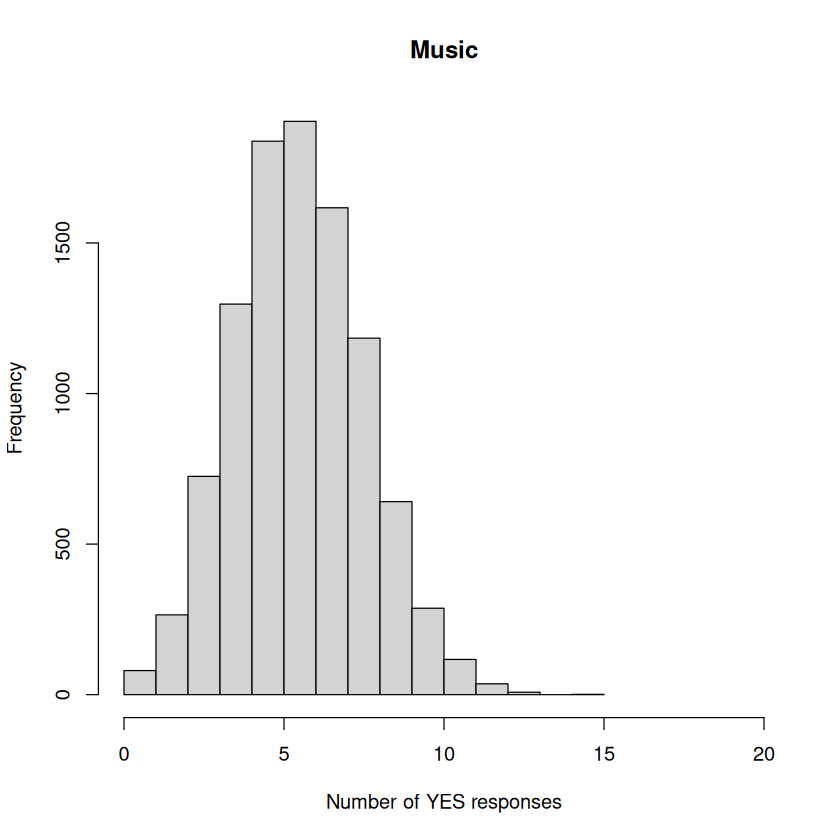

In [7]:
y.nomusic <- rbinom(n=10000, size=20, prob=0.6)
y.music   <- rbinom(n=10000, size=20, prob=0.3)
hist(y.nomusic, xlim=c(0,20), main="No Music", xlab="Number of YES responses")
hist(y.music,   xlim=c(0,20), main="Music",    xlab="Number of YES responses")

We can formalise this change in parameter value in terms of a *mean function* and *variance function*. Firstly, we will see how to parameterise the distribution in terms of a mean and variance function and then we will look at how this can be used to capture the experimental manipulation.

Now let us see how we can alter this to change depending upon the experimental condition. We will do this in a high-level conceptual way for now. We learn how this is *actually* achieved mathematically later on this unit. For now, we can simply cheat a little bit and pass the mean function the name of the experimental condition and get it to change the probability accordingly.

In [ ]:
mean.func <- function(i,x){ 
    n <- 20
    p <- 0
  
    # if the condition is "music" then p = 0.3
    if (x[i] == "music"){   
        p <- 0.3 
    } 
    
    # if the condition is "no music" then p = 0.6
    if (x[i] == "nomusic"){ 
        p <- 0.6 
    } 

    return(n*p)
}

var.func <- function(i,x){
    n <- 20
    p <- mean.func(i,x)/n

    return(n*p*(1-p))
}

# Simulate data from 12 subjects, 6 in the No Music condition and 6 in the Music condition
x <- c("nomusic", "nomusic", "nomusic", "nomusic", "nomusic", "nomusic",
       "music",   "music",   "music",   "music",   "music",   "music")
y <- rep(0,12)
n <- 20

for (i in 1:12){
    y[i] <- rbinom(n=1, size=n, prob=mean.func(i,x)/n)
}

y

[1] 15 14 10 11 12 11  5  9  5  9 10  7

So now, based on the information passed in `x`, we have simulated data where the distribution *changes* depending upon the experimental condition. In this example, the first 6 values are from the No Music condition and the second 6 values are from the Music condition. So now, we have a data-generating model *that takes the experimental manipulation into account*.

This example demonstrates a basic concept in statistics that our experimental manipulation *changes* the parameters of the distribution in some way. Usually, we conceptualise this as a change in *expected value*, but also sometimes in variance. Given that both the mean and variance of the binomial distribution involves the parameter $p$, any change to this value will affect *both* elements. In general, our statistical model aims to capture how the parameters of our proposed distribution change with some experimental manipulation, be that different conditions of a task, different clinical groups or how that change varies with some other continuous variable.

<div class="alert alert-block alert-danger"> 
<b>KEY POINT</b> A statistical model conceptualises every experimental manipulation as a change in the parameters of a probability distribution.
</div>


### Normal Example


In [10]:
mean.func <- function(){
    mu <- 5
    return(mu)
}

var.func <- function(){
    sigma2 <- 2
    return(sigma2)
}

Which would be equivalent to the model

$$
\begin{alignat*}{1}
    y_{i}              &\sim \mathcal{N}\left(\mu_{i},\sigma^{2}_{i}\right) \\
    E(y_{i})           &= \mu_{i} = 5 \\
    \text{Var}(y_{i})  &= \sigma^{2} = 2 
\end{alignat*}
$$

<div class="alert alert-block alert-success"> 
<b>THE BIG PICTURE</b> In all the examples above, we have used these distributions, mean functions, variance functions and parameter values to *simulate* data. In each case, this is our proposed *data-generating process*. It is how we *think* our data came to be. But what we do in reality is we collect some data, propose a data-generating process with *unknown* parameter values and then use to the data to *estimate* what those values are most likely to be. So, we do not know what $\mu$ and $\sigma$ are, nor how they might change across different experimental conditions. Similarly, we do not know what $p$ is from the binomial distribution. We start by assuming that these data-generating processes are correct (or at least, close enough), but the actual parameter values remain *question marks*. We have to use real data to try and work out what they are likely to be *and* how they might change in the presence of other variables or experimental manipulations. We then check to see whether our data-generating process looks accurate enough for the data we have collected. So, our core question is always whether these data-generating models look close enough to the data we have collected to be useful. If so, we can then interpret what the estimated parameter values tell us about the data. If not, we need to try something else. This is, in a nutshell, the process of statistical modelling. 
</div>

## Determining Distributions from Data
Given what we have said above, one of the trickiest aspects of this framework is determining what the *best* distribution is to model the data we have. Now, in reality, unless you are using Bayesian methods, you will have very little say in this aspect. Most classical statistical techniques are built from the assumption of one specific distribution and we generally just have to hope that this distribution will work well for us. This means that, although there are *hundreds* of possible probability distributions, you will only ever see a handful being used in the wild. Indeed, in terms of data-generating models, applied statistics tends to only use around 5 of them:

1. Normal
2. Poisson
3. Binomial
4. Gamma
5. Inverse Gamma

We do not need to go into any particular detail about these, especially as our focus in this unit is *exclusively* the normal distribution. However, it does beg the question how only 5 distributions can possibly accommodate all possible data that we might collect? The answer is that they generally *cannot*. Instead, we need to decide which of the available options is most suitable, apply it to the data and then try to understand whether the conclusions from that process are *valid enough* to be useful. This is a fundamental constraint of the classical statistics world.

### How Do We Choose a Distribution?

### How Do We Check?
... As an example, the code below shows 9 examples of drawing data from a normal distribution and then plotting it. In this example, $n = 5$, which is a very small sample. Notice how difficult it is to assess the actual form of distribution from the sample, despite us knowing that each one was drawn from the *exact same normal distribution*.

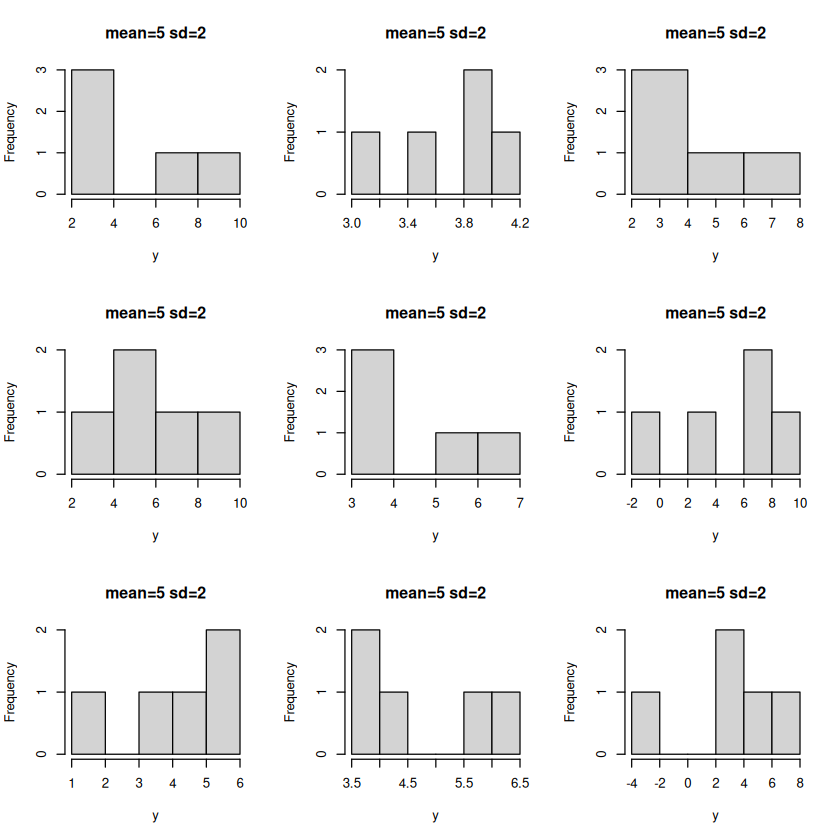

In [11]:
n     <- 5
mu    <- 5
sigma <- 2

par(mfrow=c(3,3))

for (i in 1:9){
    y            <- rnorm(n, mean=mu, sd=sigma)
    sample.mu    <- mean(y)
    sample.sigma <- sd(y)
    
    hist(y, main=paste0("mean=",round(mu,2)," sd=",round(sigma,2)))
}

par(mfrow=c(1,1)) # reset the display

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Alter the code above for different values of <code>n</code>. At what sample size do you think assuming normality based on the shape of the sample distribution is reasonable? What does this suggest about how reliable it is to use the basic shape of the sample distribution to determine the population distribution? Now consider how variable the estimates are for the <i>mean</i> and <i>standard deviation</i>, as written in the title of each histogram. Remember, the true values are a mean of 5 and a standard deviation of 2. How does this variability change with different values of <code>n</code> and what does this suggest about our ability to accurately estimate the population parameters from a sample?
</div>

### What If We Are Wrong?
... So, remembering the quote from George Box, we will *always* get the distribution "wrong" because the distribution is a *model* and no model is perfect. Our aim is then to choose something that is *as close as possible* such that the numbers produced by the model are useful. However, we can still make choices that are *more appropriate* or *less appropriate*.

As an example, let us go back to the auditory stimuli example from earlier. Previously, we used a binomial distribution to represent the number of "yes" responses given by each subject under different conditions. However, you may have noticed from generating the histograms that does not seem all that dissimilar to a normal distribution. Indeed if we take $\mu = np$ and $\sigma = \sqrt{np(1-p)}$ then we can create a *normal approximation* to the binomial, as shown below.

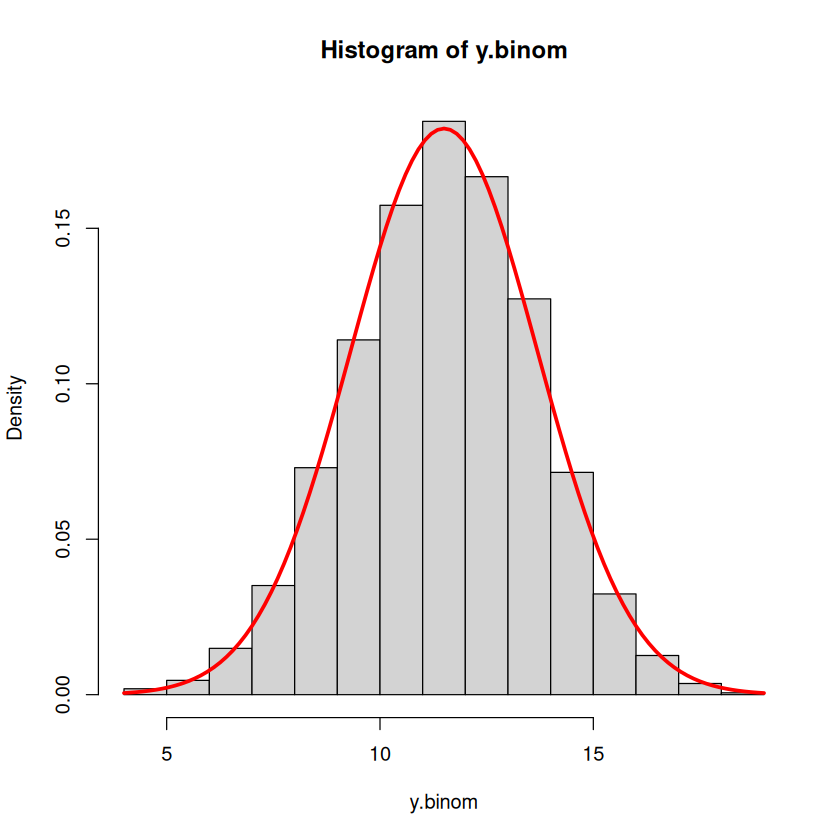

In [12]:
# binomial random variable
n <- 20
p <- 0.6
y.binom <- rbinom(n=10000, size=n, prob=p)

# normal approximation
mu    <- n*p
sigma <- sqrt(n*p*(1-p))

# binomial histogram and normal density overlay
hist(y.binom, freq=FALSE) 
curve(dnorm(x+0.5, mean=mu, sd=sigma), add=TRUE, col="red", lwd=3)


So, what would happen if we decided to use a normal distribution instead of a binomial distribution as the model for this experiment?

So, what would the binomial distribution say is the probability of getting 21 "yes" responses from only 20 trials?

In [13]:
pbinom(q=21, size=n, prob=p, lower.tail=FALSE)

[1] 0

So, quite rightly, it would be *impossible* to have a subject give 21 "yes" responses when there are only 20 trials. Now, let us see what the normal approximation says

In [14]:
pnorm(q=21, mean=mu, sd=sigma, lower.tail=FALSE)

[1] 1.996199e-05

Admittedly, this is a small value ($p = 0.00002$). But, it is not 0. So the normal probability model tells us that there is *some chance* of a subject giving 21 responses from only 20 trials. This is clearly nonsense, but highlights the sort of thing that happens when an *inappropriate* distribution is chosen to model an experiment.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Now consider the opposite situation, where someone decides to model a *continuous* outcome using the binomial distribution. What problems do you think could occur? 
</div>

## Summary

<div class="alert alert-block alert-warning"> 
<b>TEST QUESTIONS</b> 

Use the questions below to check your understanding of all the materials from this week.

1. What are the two sources of variance in any dataset?
2. How do these sources relate to <i>reducible</i> and <i>irriducible</i> error?
3. What does it mean to say that a random variable is a <i>variance generator</i>?
4. What do the parameters <i>n</i> and <i>p</i> mean in the context of the binomial distribution?
5. How do we usually conceptualise the <i>effect</i> of an experimental manipulation in terms of the parameters of a probability distribution?
6. How do mean and variance functions allow the effect of an experimental manipulation to be integrated into our model of the data-generating process?
7. Do we always have freedom to choose exactly the distribution we want to use to model our data?
8. Can we always rely on the sample distribution to tell us whether our chosen distribution is suitable?
9. Name one possible consequence of using a *continuous* distribution to model a *discrete* outcome.
10. Name one possible consequence of using a *discrete* distribution to model a *continuous* outcome.
</div>